# 14 - Paper Figures

**Figure 1:** Time dynamics of the homogeneous mean field approximation vs. stochastic simulation for a single error value.

**Figure 2:** `n_errors × n_channels` grid showing how dynamics evolve as error and channel topology change.

Test parameters: `N=100`, `num_runs=10`

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.models.NSI import NSI
from src.models.channel import single_flip_channel, simplex_channel, star_channel

In [2]:
N       = 100
num_runs = 10
T       = 1000
beta    = 0.01
k       = 4

COLORS = ['crimson', 'steelblue', 'goldenrod', 'mediumseagreen']

In [3]:
def run_comparison(channel, N, T, beta, k, num_runs):
    """
    Run mean field analytic and stochastic simulation for a given channel.

    Returns
    -------
    analytic_arr : ndarray (L, n_msg)  - mean field trajectory
    sim_mean     : ndarray (L, n_msg)  - simulation mean
    sim_ci       : ndarray (L, n_msg)  - 95% CI half-widths
    """
    n_msg = channel.shape[0]
    model = NSI(N=N, T=T, P=channel)

    # --- analytic mean field ---
    seed_analytic = np.zeros(n_msg)
    seed_analytic[0] = 1 / N
    analytic_out = model.homogeneous_analytic(beta=beta, k=k, seedI=seed_analytic)
    analytic_arr = np.array(analytic_out.I)           # (T, n_msg)

    # --- stochastic simulations ---
    seed_sim = np.zeros(n_msg)
    seed_sim[0] = 1
    runs = []
    for _ in range(num_runs):
        out = model.homogeneous_simulation(
            beta=beta, k=k, seedI=seed_sim.copy(), density=True, pbar_on=False
        )
        runs.append(np.array(out.I))

    sim_arr = np.array(runs)                          # (num_runs, T', n_msg)

    # align lengths (pbar_on=False iterates T times vs analytic T-1 times)
    L = min(analytic_arr.shape[0], sim_arr.shape[1])
    analytic_arr = analytic_arr[:L]
    sim_arr      = sim_arr[:, :L, :]

    sim_mean = np.mean(sim_arr, axis=0)
    sim_ci   = 1.96 * np.std(sim_arr, axis=0) / np.sqrt(num_runs)

    return analytic_arr, sim_mean, sim_ci

## Figure 1: Single-Error Time Dynamics
Binary symmetric channel at a single error value.
Solid lines = simulation mean ± 95% CI (shaded); dashed lines = mean field.

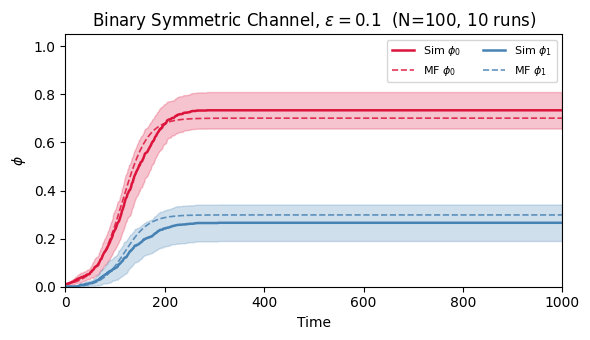

In [4]:
epsilon = 0.1
channel = single_flip_channel(1, epsilon)   # 2x2 binary symmetric

analytic_arr, sim_mean, sim_ci = run_comparison(channel, N, T, beta, k, num_runs)

t = np.arange(len(sim_mean))
n_msg = channel.shape[0]

fig, ax = plt.subplots(figsize=(6, 3.5))

for dim in range(n_msg):
    color = COLORS[dim]
    label = fr'$\phi_{dim}$'

    # simulation
    ax.plot(t, sim_mean[:, dim], color=color, lw=1.8, label=f'Sim {label}')
    ax.fill_between(
        t,
        np.clip(sim_mean[:, dim] - sim_ci[:, dim], 0, 1),
        np.clip(sim_mean[:, dim] + sim_ci[:, dim], 0, 1),
        alpha=0.25, color=color
    )

    # mean field
    ax.plot(t, analytic_arr[:, dim], color=color, lw=1.2,
            linestyle='--', alpha=0.85, label=f'MF {label}')

ax.set_xlabel('Time')
ax.set_ylabel(r'$\phi$')
ax.set_title(fr'Binary Symmetric Channel, $\varepsilon = {epsilon}$  (N={N}, {num_runs} runs)')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, T)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Figure 2: Dynamics Across Errors and Channel Types
`n_errors × n_channels` grid.  
Rows = error values, columns = channel topologies.  
Same visual encoding as Figure 1.

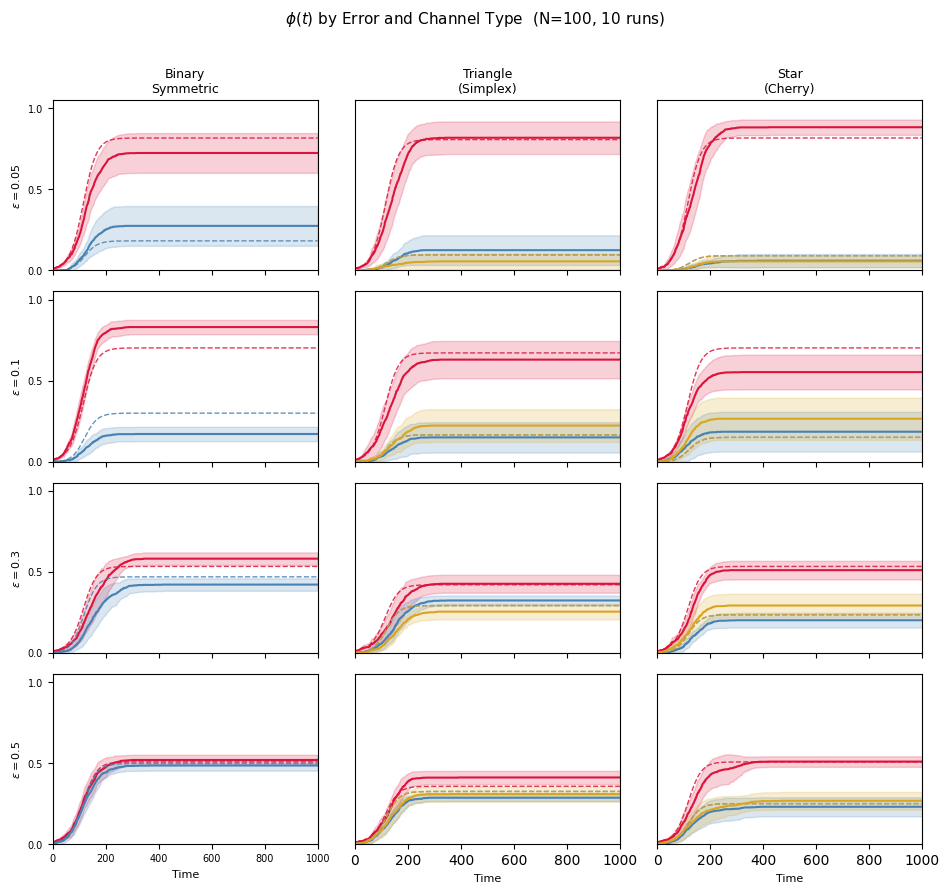

In [5]:
errors = [0.05, 0.1, 0.3, 0.5]

channel_defs = [
    ('Binary\nSymmetric',  lambda e: single_flip_channel(1, e), 2),
    ('Triangle\n(Simplex)', lambda e: simplex_channel(3, e),    3),
    ('Star\n(Cherry)',      lambda e: star_channel(3, e),       3),
]

n_errors   = len(errors)                    # x1 (rows)
n_channels = len(channel_defs)              # x2 (cols)

fig, axs = plt.subplots(
    n_errors, n_channels,
    figsize=(n_channels * 3.2, n_errors * 2.2),
    sharex=True
)

for col_idx, (ch_name, ch_fn, n_msg) in enumerate(channel_defs):
    for row_idx, err in enumerate(errors):

        channel = ch_fn(err)
        analytic_arr, sim_mean, sim_ci = run_comparison(
            channel, N, T, beta, k, num_runs
        )

        ax = axs[row_idx, col_idx]
        t  = np.arange(len(sim_mean))

        for dim in range(n_msg):
            color = COLORS[dim]
            ax.plot(t, sim_mean[:, dim], color=color, lw=1.5)
            ax.fill_between(
                t,
                np.clip(sim_mean[:, dim] - sim_ci[:, dim], 0, 1),
                np.clip(sim_mean[:, dim] + sim_ci[:, dim], 0, 1),
                alpha=0.2, color=color
            )
            ax.plot(t, analytic_arr[:, dim], color=color,
                    linestyle='--', lw=1.0, alpha=0.85)

        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, T)

        # labels
        if row_idx == 0:
            ax.set_title(ch_name, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(fr'$\varepsilon={err}$', fontsize=8)
            ax.set_yticks([0, 0.5, 1])
            ax.tick_params(labelsize=7)
        else:
            ax.set_yticks([])
        if row_idx == n_errors - 1:
            ax.set_xlabel('Time', fontsize=8)

plt.suptitle(
    fr'$\phi(t)$ by Error and Channel Type  (N={N}, {num_runs} runs)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()